# Different image functions at similar loss

An image reconstruction network makes weight-space exploration directly visible: the same input digit can produce different reconstructed strokes.

Start with a network fitted by stochastic gradient descent, then explore its weights under a training-loss constraint. Examine reconstruction errors, image changes and matrix properties across the resulting networks.

In [1]:
import gzip
import time
from pathlib import Path

import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree
import matplotlib.pyplot as plt
import numpy as np

from walk import random_walk

def read_images(name):
    with gzip.open(Path('data') / name, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 784).astype(np.float32) / 255

def read_labels(name):
    with gzip.open(Path('data') / name, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=8)

# A fixed subset of the official training set; the official test set is separate.
# Neither test images nor their labels enter SGD or the weight walk.
rng = np.random.default_rng(41)
train_images = read_images('train-images-idx3-ubyte.gz')
train_indices = rng.permutation(len(train_images))[:10000]
x_train = jnp.asarray(train_images[train_indices])
x_test = jnp.asarray(read_images('t10k-images-idx3-ubyte.gz')[:5000])
y_test = read_labels('t10k-labels-idx1-ubyte.gz')[:5000]
del train_images

## Reconstruct images through a narrow latent space

The encoder maps each image to a shorter latent vector, and the decoder maps that vector back to pixel intensities. This bottleneck makes reconstruction depend on which features the encoder retains and how the decoder combines them.

Together they define $f_\theta(x)$, where $x$ is the flattened input image and $\theta$ contains every weight and bias. The training loss is the mean squared difference between input and reconstruction,

$$L(\theta)=\frac{1}{nd}\sum_{i=1}^{n}\|f_\theta(x_i)-x_i\|_2^2.$$

Here $n$ is the number of training images and $d$ the number of pixels. Averaging over images and pixels allows different allocations of reconstruction error to produce the same loss.

In [2]:
# The bottleneck is the middle hidden layer. Tanh keeps the maps smooth;
# sigmoid restricts reconstructed intensities to the original [0, 1] range.
widths = [784, 64, 16, 64, 784]
keys = jax.random.split(jax.random.PRNGKey(17), len(widths) - 1)
layers = [(jax.random.normal(key, (a, b)) * jnp.sqrt(2 / (a + b)), jnp.zeros(b))
          for key, a, b in zip(keys, widths[:-1], widths[1:])]
theta, unpack = ravel_pytree(layers)

def reconstruct(theta, x):
    layers = unpack(theta)
    for weight, bias in layers[:-1]:
        x = jnp.tanh(x @ weight + bias)
    weight, bias = layers[-1]
    return jax.nn.sigmoid(x @ weight + bias)

@jax.jit
def mse(theta, x):
    return jnp.mean((reconstruct(theta, x) - x)**2)

@jax.jit
def training_loss(theta):
    return mse(theta, x_train)

@jax.jit
def sgd_epoch(theta, velocity, order, rate):
    def update(state, indices):
        theta, velocity = state
        gradient = jax.grad(mse)(theta, x_train[indices])
        velocity = 0.9 * velocity + gradient
        return (theta - rate * velocity, velocity), None
    return jax.lax.scan(update, (theta, velocity), order.reshape(-1, 250))[0]

SGD first reduces reconstruction error. The late trajectory shows when fitting has slowed enough to provide a reference for weight-space exploration. Enlarging the final part of the curve makes the remaining drift visible.

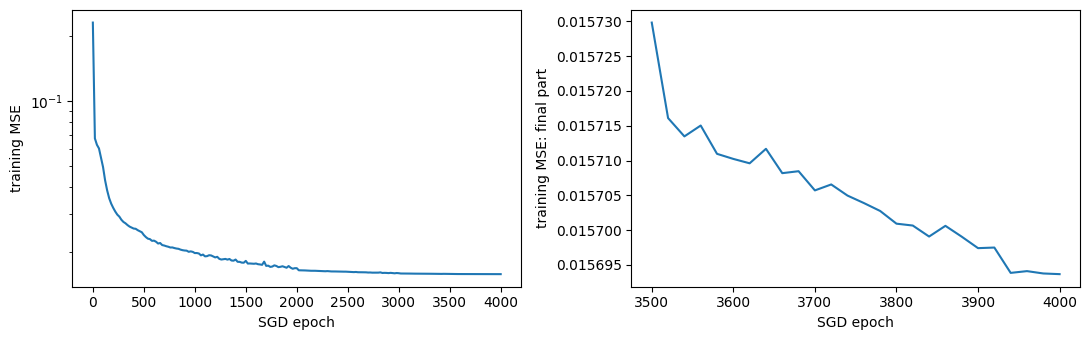

Training seconds: 1236.1
Relative loss decrease over final 500 epochs: 0.230%


In [3]:
# Momentum SGD only. The schedule is fixed before looking at any alternative
# model or image-property measurements. Full training loss is checked periodically.
velocity = jnp.zeros_like(theta)
history = [(0, float(training_loss(theta)))]
started = time.perf_counter()
for epoch in range(4000):
    rate = 1.0 if epoch < 2000 else 0.3 if epoch < 3000 else 0.1 if epoch < 3500 else 0.03
    order = jnp.asarray(rng.permutation(len(x_train)))
    theta, velocity = sgd_epoch(theta, velocity, order, rate)
    if (epoch + 1) % 20 == 0:
        history.append((epoch + 1, float(training_loss(theta))))
theta0 = theta
history = np.array(history)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(history[:, 0], history[:, 1])
axes[0].set(xlabel='SGD epoch', ylabel='training MSE', yscale='log')
tail = history[history[:, 0] >= 3500]
axes[1].plot(tail[:, 0], tail[:, 1])
axes[1].ticklabel_format(axis='y', style='plain', useOffset=False)
axes[1].set(xlabel='SGD epoch', ylabel='training MSE: final part')
plt.tight_layout()
plt.show()
print(f'Training seconds: {time.perf_counter()-started:.1f}')
print(f'Relative loss decrease over final 500 epochs: {(tail[0,1]-tail[-1,1])/tail[0,1]:.3%}')

## Explore weights within the loss band

Let $\theta_0$ be the fitted weights, $L_0=L(\theta_0)$, and $\varepsilon$ the allowed absolute loss difference. The permitted region is

$$\mathcal A=\{\theta: |L(\theta)-L_0|\leq\varepsilon\}.$$

When the local loss gradient $g=\nabla L(\theta)$ is nonzero, project a random direction $z$ onto the tangent plane of the loss level:

$$v=z-\frac{g^\top z}{g^\top g}g.$$

The proposal $\theta+h\,v/\|v\|$ has zero first-order loss change. At $g=0$, every direction is first-order flat. Curvature can take a finite proposal outside the band, so a short correction along the loss gradient attempts to bring it back. Evaluating the full training loss determines acceptance at each proposed state.

The shared `random_walk` function implements this update. Different random directions produce the paths below.

walk 1 accepted proposals: 77 / 240
walk 2 accepted proposals: 84 / 240
walk 3 accepted proposals: 75 / 240
walk 4 accepted proposals: 79 / 240


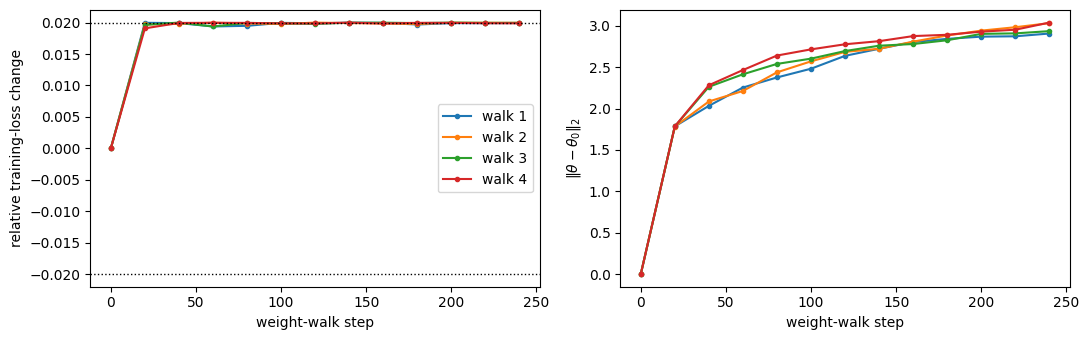

In [4]:
# These settings are fixed before measuring alternative outputs or properties.
# Every endpoint is kept, including one that makes little progress.
walk_seeds = [101, 202, 303, 404]
paths = [random_walk(training_loss, theta0, seed=seed, step_size=0.12,
                     steps=240, relative_band=0.02, persistence=0.9, record_every=20)
         for seed in walk_seeds]
population = jnp.stack([theta0] + [jnp.asarray(path[0][-1]) for path in paths])
names = ['SGD'] + [f'walk {i+1}' for i in range(len(paths))]
reference_loss = float(training_loss(theta0))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for i, (weights, losses, accepted) in enumerate(paths):
    steps = np.arange(len(losses)) * 20
    axes[0].plot(steps, losses / reference_loss - 1, '.-', label=names[i+1])
    axes[1].plot(steps, np.linalg.norm(weights - np.array(theta0), axis=1), '.-')
    print(names[i+1], 'accepted proposals:', int(accepted.sum()), '/', len(accepted))
axes[0].axhline(0.02, color='k', ls=':', lw=1)
axes[0].axhline(-0.02, color='k', ls=':', lw=1)
axes[0].set(xlabel='weight-walk step', ylabel='relative training-loss change')
axes[0].legend()
axes[1].set(xlabel='weight-walk step', ylabel=r'$\|\theta-\theta_0\|_2$')
plt.tight_layout()
plt.show()

## Measure function distance on test images

Compare the reconstructions produced by each endpoint with those of the SGD reference:

$$D(f_\theta,f_{\theta_0})=
\sqrt{\frac{1}{md}\sum_{i=1}^{m}\|f_\theta(x_i)-f_{\theta_0}(x_i)\|_2^2}.$$

Here $m$ is the number of test images. The distance measures the typical pixel change between two networks' reconstructions. Plotting it against weight distance connects motion in parameter space to changes in the image function.

model      training MSE     test MSE   output RMS from SGD
SGD            0.015694     0.017459              0.000000
walk 1         0.016007     0.017755              0.017685
walk 2         0.016007     0.017740              0.017320
walk 3         0.016007     0.017725              0.017464
walk 4         0.016006     0.017749              0.017393


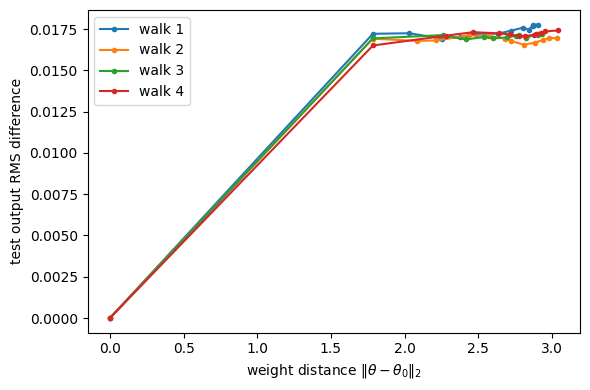

In [5]:
output = np.stack([np.array(reconstruct(theta, x_test)) for theta in population])
per_image_error = np.mean((output - np.array(x_test)[None])**2, axis=2)
train_loss = np.array([float(training_loss(theta)) for theta in population])
test_loss = per_image_error.mean(axis=1)
output_rms = np.sqrt(np.mean((output - output[0])**2, axis=(1, 2)))

print(f'{"model":<9} {"training MSE":>13} {"test MSE":>12} {"output RMS from SGD":>21}')
for name, train, test, distance in zip(names, train_loss, test_loss, output_rms):
    print(f'{name:<9} {train:13.6f} {test:12.6f} {distance:21.6f}')

# Function distances along every stream, on the same fixed test-image subset.
probe = x_test[:500]
reference_output = reconstruct(theta0, probe)
fig, ax = plt.subplots(figsize=(6, 4))
for i, (weights, _, _) in enumerate(paths):
    function_distance = [float(jnp.sqrt(jnp.mean((reconstruct(t, probe)-reference_output)**2)))
                         for t in weights]
    ax.plot(np.linalg.norm(weights-np.array(theta0), axis=1), function_distance,
            '.-', label=names[i+1])
ax.set(xlabel=r'weight distance $\|\theta-\theta_0\|_2$', ylabel='test output RMS difference')
ax.legend()
plt.tight_layout()
plt.show()

## Inspect the image functions

The same handwritten digits are reconstructed by every model. The examples are the first two occurrences of each digit in the test set.

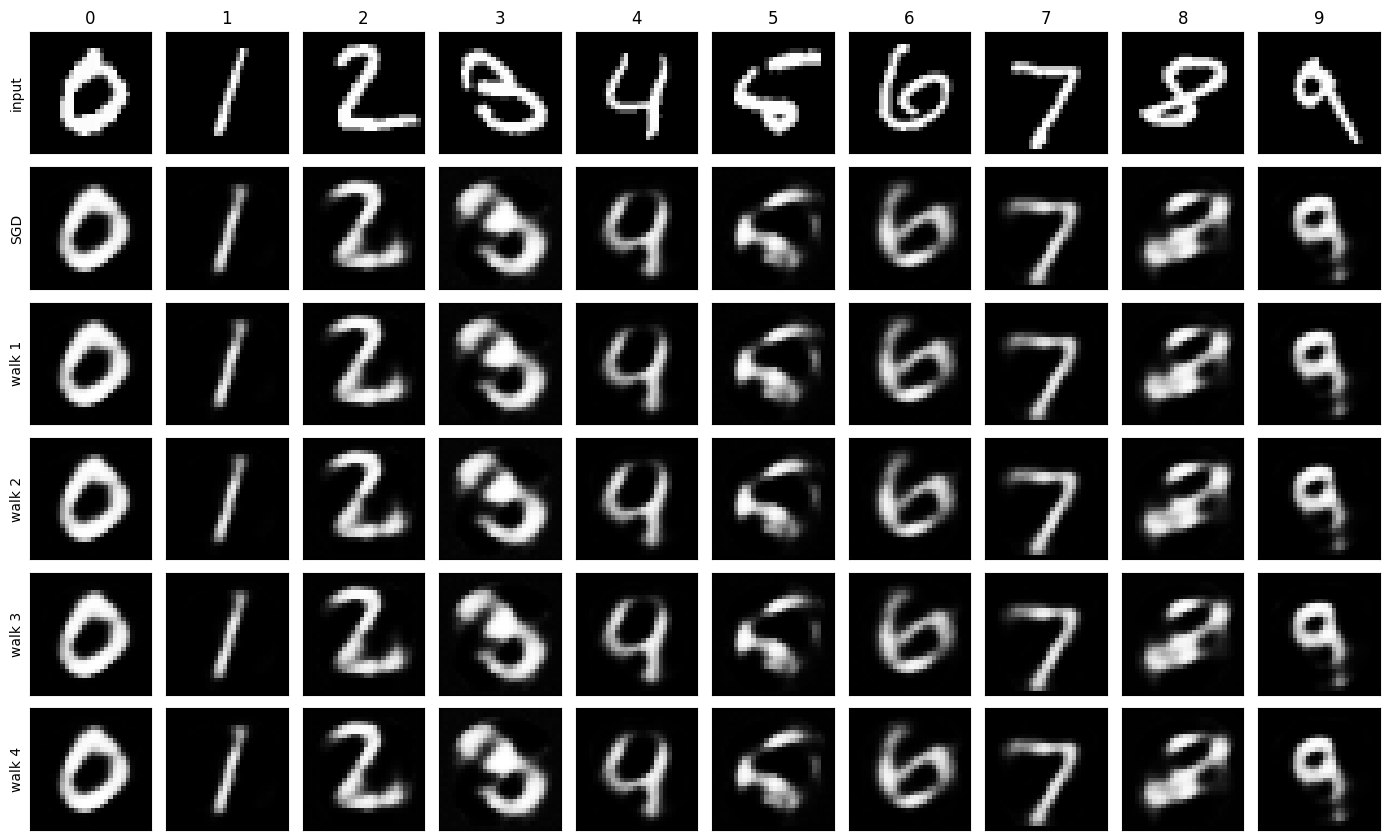

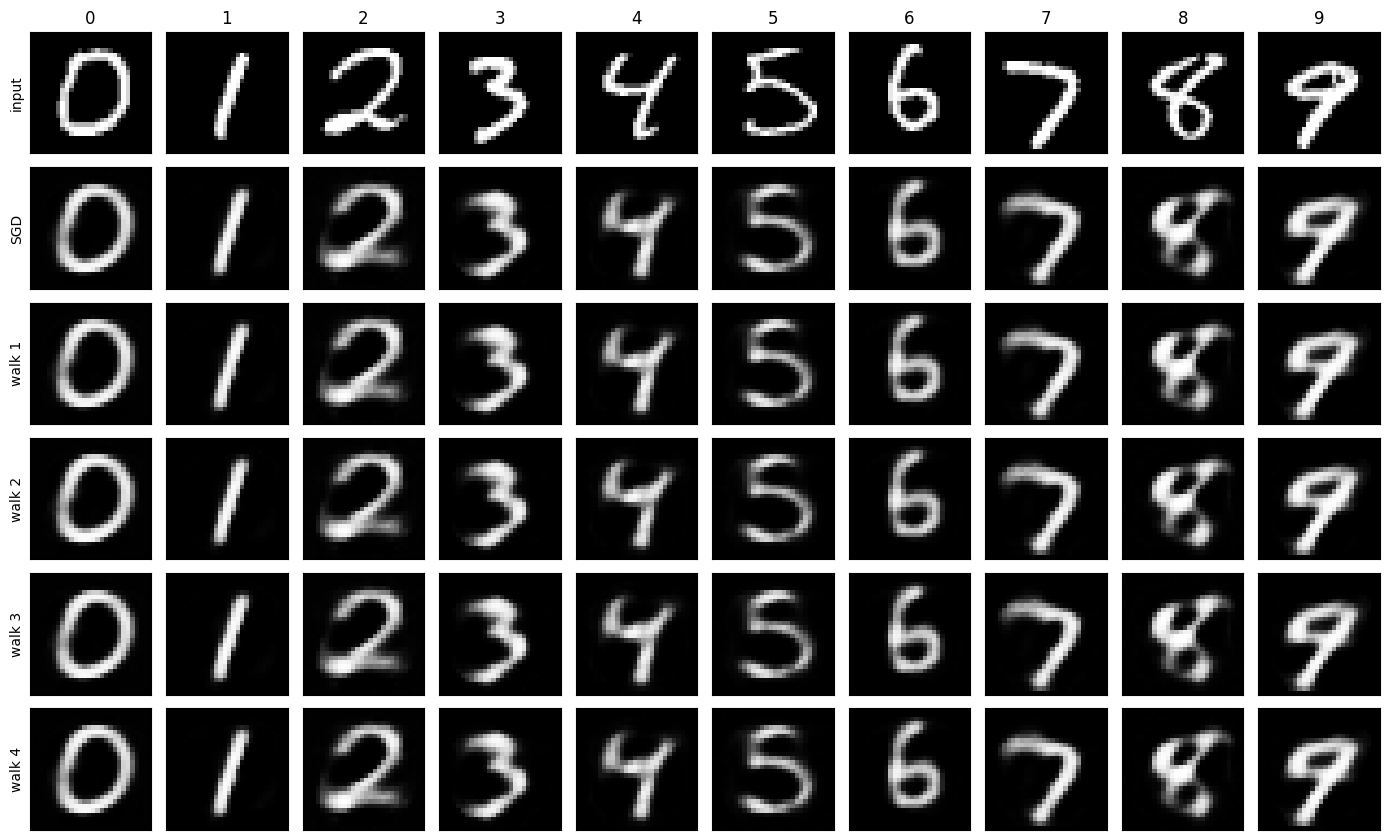

In [6]:
# Two fixed examples of each digit. All four endpoints appear in both grids.
example_indices = [[np.flatnonzero(y_test == digit)[occurrence] for digit in range(10)]
                   for occurrence in range(2)]
for indices in example_indices:
    fig, axes = plt.subplots(6, 10, figsize=(14, 8.5))
    rows = [np.array(x_test)[indices]] + [images[indices] for images in output]
    for row, images in enumerate(rows):
        for col, img in enumerate(images):
            axes[row, col].imshow(img.reshape(28, 28), cmap='gray', vmin=0, vmax=1)
            axes[row, col].set(xticks=[], yticks=[])
            if row == 0:
                axes[row, col].set_title(str(y_test[indices[col]]))
        axes[row, 0].set_ylabel((['input'] + names)[row])
    plt.tight_layout()
    plt.show()

Subtracting the reference reconstruction isolates the pixel changes introduced by the weight walk. Positive and negative values mean brighter and darker predictions at the same pixel. All panels use a common signed scale.

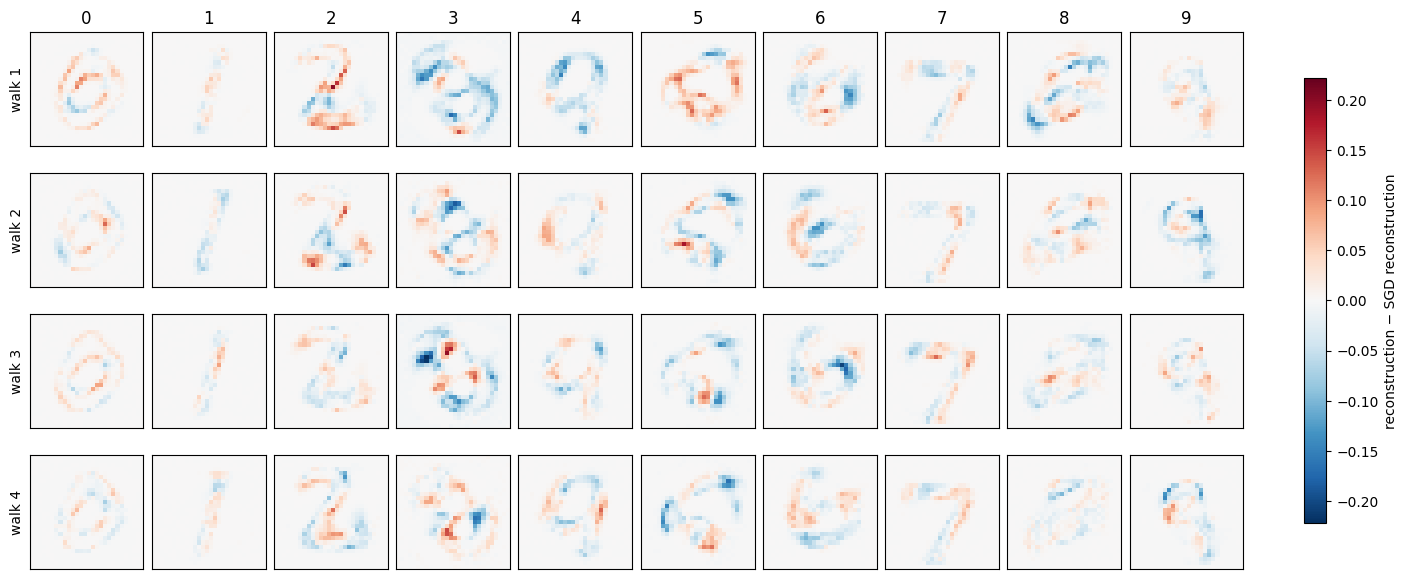

In [7]:
indices = example_indices[0]
differences = output[1:, indices] - output[0, indices]
limit = np.max(np.abs(differences))
fig, axes = plt.subplots(4, 10, figsize=(14, 5.8), constrained_layout=True)
for row in range(4):
    for col in range(10):
        image = axes[row, col].imshow(differences[row, col].reshape(28, 28),
                                      cmap='RdBu_r', vmin=-limit, vmax=limit)
        axes[row, col].set(xticks=[], yticks=[])
        if row == 0:
            axes[row, col].set_title(str(y_test[indices[col]]))
    axes[row, 0].set_ylabel(names[row+1])
fig.colorbar(image, ax=axes, shrink=0.8, label='reconstruction − SGD reconstruction')
plt.show()

## How is reconstruction error distributed?

For image $i$, define $\Delta_i(\theta)$ as its reconstruction MSE minus the reference model's MSE. A negative value means that image is reconstructed more accurately; a positive value means less accurately. A small average change can combine improvements on some images with deterioration on others.

Group these changes by digit to compare class-level effects, then examine their distribution across individual images.

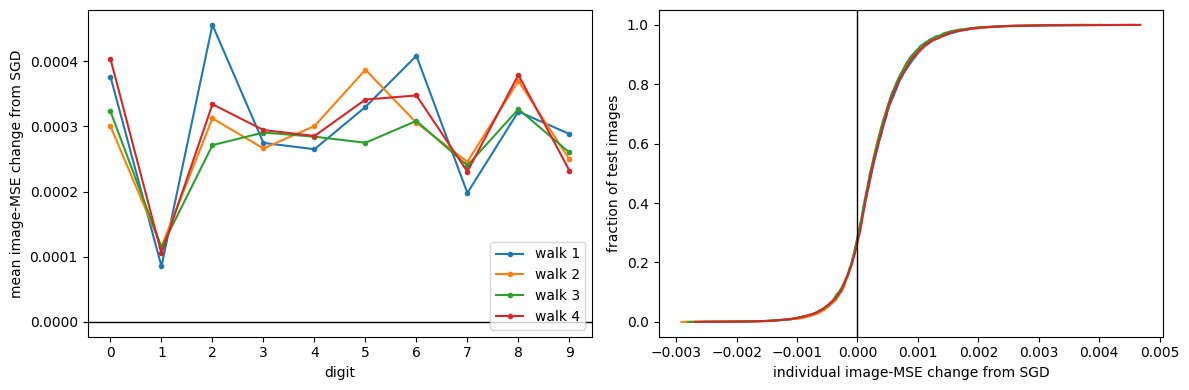

Fraction of test images with lower error than SGD:
walk 1: 27.4%
walk 2: 28.4%
walk 3: 28.2%
walk 4: 26.7%


In [8]:
error_change = per_image_error[1:] - per_image_error[0]
digit_error = np.array([[errors[y_test == digit].mean() for digit in range(10)]
                        for errors in per_image_error])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(4):
    axes[0].plot(range(10), digit_error[i+1]-digit_error[0], '.-', label=names[i+1])
    axes[1].plot(np.sort(error_change[i]), np.linspace(0, 1, len(y_test)), label=names[i+1])
axes[0].axhline(0, color='k', lw=1)
axes[0].set(xlabel='digit', ylabel='mean image-MSE change from SGD', xticks=range(10))
axes[0].legend()
axes[1].axvline(0, color='k', lw=1)
axes[1].set(xlabel='individual image-MSE change from SGD', ylabel='fraction of test images')
plt.tight_layout()
plt.show()
print('Fraction of test images with lower error than SGD:')
for name, delta in zip(names[1:], error_change):
    print(f'{name}: {np.mean(delta < 0):.1%}')

## Layer spectra and input sensitivity

The singular values of each weight matrix describe its linear gains. The stable rank

$$\operatorname{srank}(W)=\frac{\|W\|_F^2}{\|W\|_2^2}
=\frac{\sum_j\sigma_j^2}{\sigma_1^2}$$

summarizes how spread out those gains are.

The encoder--decoder structure also constrains the local response of the full network. If the latent vector has dimension $r$, then $f_\theta=D_\theta\circ E_\theta$ and

$$J_\theta(x)=J_{D_\theta}(E_\theta(x))J_{E_\theta}(x),
\qquad \operatorname{rank}J_\theta(x)\leq r.$$

This rank ceiling holds for every choice of weights. The weights determine the strength and directions of the response below that ceiling. For the input Jacobian $J_\theta(x)=\partial f_\theta(x)/\partial x$ and an isotropic unit-length random direction $v$,

$$\mathbb E_v\|J_\theta(x)v\|_2^2=\frac{\|J_\theta(x)\|_F^2}{d}.$$

Directional derivatives estimate this average squared sensitivity. Using the same test images and perturbation directions for every network gives a paired comparison of their responses to input changes.

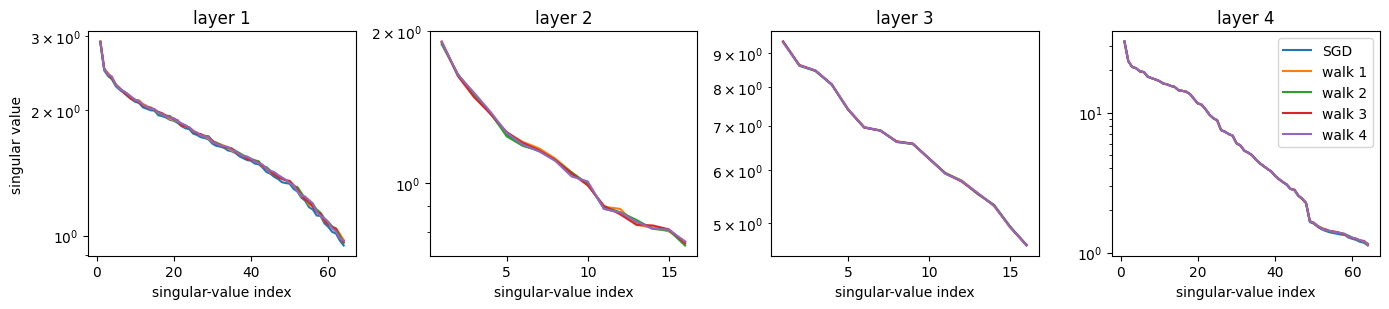

model     layer stable ranks                        input directional RMS gain
SGD       [22.252  6.138  8.545  7.315]                               0.606095
walk 1    [22.589  6.217  8.55   7.315]                               0.612949
walk 2    [22.499  6.24   8.544  7.315]                               0.611665
walk 3    [22.424  6.096  8.534  7.324]                               0.610490
walk 4    [22.66   6.141  8.583  7.318]                               0.609618


In [9]:
spectra = [[np.linalg.svd(np.array(w), compute_uv=False) for w, b in unpack(theta)]
           for theta in population]
stable_ranks = np.array([[np.sum(s*s)/(s[0]*s[0]) for s in model] for model in spectra])
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for layer, ax in enumerate(axes):
    for name, model in zip(names, spectra):
        values = model[layer]
        ax.plot(np.arange(1, len(values)+1), values, label=name)
    ax.set(xlabel='singular-value index', title=f'layer {layer+1}', yscale='log')
axes[0].set_ylabel('singular value')
axes[-1].legend()
plt.tight_layout()
plt.show()

probe_images = x_test[:512]
probe_rng = np.random.default_rng(73)
directions = jnp.asarray(probe_rng.choice([-1., 1.], size=(3, *probe_images.shape)).astype(np.float32)
                         / np.sqrt(probe_images.shape[1]))

@jax.jit
def directional_gain(theta, direction):
    _, response = jax.jvp(lambda x: reconstruct(theta, x), (probe_images,), (direction,))
    return jnp.mean(jnp.sum(response**2, axis=1))

jacobian_gain = np.array([np.sqrt(np.mean([float(directional_gain(theta, v)) for v in directions]))
                          for theta in population])

print(f'{"model":<9} {"layer stable ranks":<40} {"input directional RMS gain":>27}')
for name, ranks, gain in zip(names, stable_ranks, jacobian_gain):
    print(f'{name:<9} {str(np.round(ranks, 3)):<40} {gain:27.6f}')

## Properties of the discovered image functions

The alternatives introduce modest changes to reconstructed strokes. More than a quarter of the test images receive lower reconstruction error from each alternative, while average test error rises overall and within every digit class. The networks redistribute error among individual images.

The layer spectra remain nearly unchanged, and average input sensitivity changes only slightly. The changed reconstructions therefore coexist with closely matched values of these matrix and sensitivity summaries.

The paths quickly reach the upper loss boundary. Subsequent weight movement adds little output distance, and rejected proposals increasingly restrict progress. The resulting populations describe the nearby image functions reached by this traversal.